In [12]:
from pathlib import Path
import importlib, json, os, random, sys, types
os.environ.setdefault('PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION','python')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import yaml
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
Image.MAX_IMAGE_PIXELS=None
SEED=42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
print(sys.executable,torch.__version__,torch.cuda.is_available())

/home/qinbw/anaconda3/envs/qinbowen/bin/python 1.12.1+cu113 True


In [17]:
VISIUM_DIR=Path('/data200T/STORM/HMDB/HM0543')
SQUALL_CODE_DIR=Path('/home/qinbw/STORM_codebase')
SQUALL_CONFIG=Path('/home/qinbw/STORM_codebase/config.yaml')
SQUALL_CHECKPOINT=Path('/data200T/STORM/HD_inference/SQUALL_lowres.pth')
OUTPUT_DIR=Path('./squall_visium_clustering_output_HM0543')
PATCH_SIZE=224
STRIDE=16
BATCH_SIZE=32
RESOLUTION=0.5
N_CLUSTERS=7
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
for path in [VISIUM_DIR,SQUALL_CODE_DIR,SQUALL_CONFIG,SQUALL_CHECKPOINT]:
    if not path.exists(): raise FileNotFoundError(path)
DEVICE

device(type='cuda')

In [18]:
def read_positions(root):
    spatial=root/'spatial'
    path=next((p for p in [spatial/'tissue_positions.csv',spatial/'tissue_positions_list.csv'] if p.is_file()),None)
    if path is None: raise FileNotFoundError(spatial)
    first=str(pd.read_csv(path,header=None,nrows=1).iloc[0,0]).lower()
    if first in {'barcode','barcodes'}:
        frame=pd.read_csv(path)
    else:
        frame=pd.read_csv(path,header=None).iloc[:,:6]
        frame.columns=['barcode','in_tissue','array_row','array_col','pxl_row_in_fullres','pxl_col_in_fullres']
    frame['barcode']=frame['barcode'].astype(str)
    numeric=['in_tissue','array_row','array_col','pxl_row_in_fullres','pxl_col_in_fullres']
    frame[numeric]=frame[numeric].apply(pd.to_numeric,errors='coerce')
    return frame.dropna(subset=numeric).loc[lambda x:x.in_tissue.eq(1)].set_index('barcode')

def find_hires(root):
    paths=[p for p in (root/'spatial').iterdir() if 'hires' in p.name.lower() and p.suffix.lower() in {'.png','.jpg','.jpeg','.tif','.tiff'}]
    if not paths: raise FileNotFoundError(root/'spatial')
    return sorted(paths)[0]

def read_scale(root):
    paths=[root/'spatial'/'sub_scalefactors_json.json',root/'spatial'/'sub_scalefactors_json.json']
    path=next((p for p in paths if p.is_file()),None)
    if path is None: raise FileNotFoundError(root/'spatial')
    return float(json.loads(path.read_text())['tissue_hires_scalef'])

positions=read_positions(VISIUM_DIR)
image=np.asarray(Image.open(find_hires(VISIUM_DIR)).convert('RGB'))
hires_scale=read_scale(VISIUM_DIR)
xy=positions[['pxl_col_in_fullres','pxl_row_in_fullres']].to_numpy(np.float32)*hires_scale
print(len(positions),image.shape,hires_scale)

4948 (1991, 2000, 3) 0.47359696


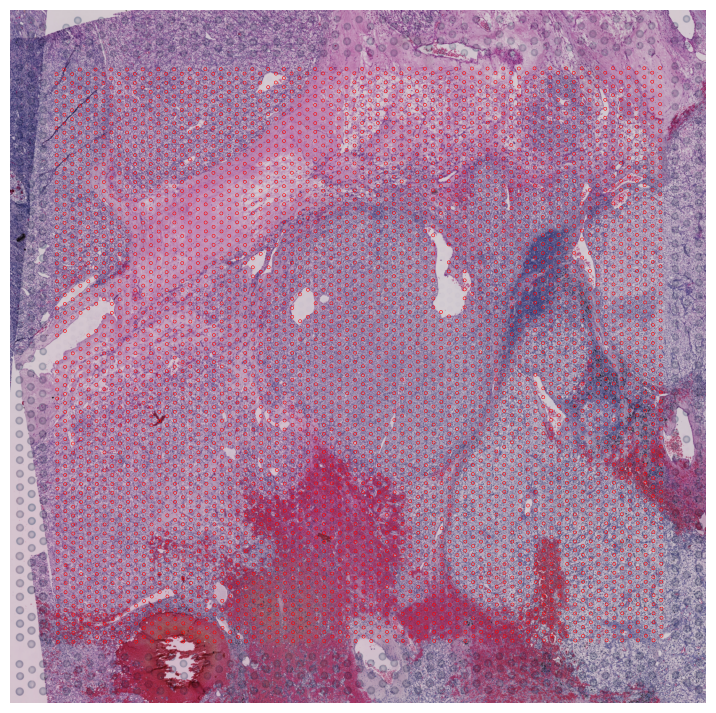

In [19]:
plt.figure(figsize=(9,9))
plt.imshow(image)
plt.scatter(xy[:,0],xy[:,1],s=5,facecolors='none',edgecolors='red',linewidths=.4)
plt.xlim(0,image.shape[1])
plt.ylim(image.shape[0],0)
plt.axis('off')
plt.show()

In [20]:
class AttrDict(dict):
    __getattr__=dict.__getitem__

def attrs(value):
    if isinstance(value,dict): return AttrDict({key:attrs(item) for key,item in value.items()})
    if isinstance(value,list): return [attrs(item) for item in value]
    return value

models_dir=SQUALL_CODE_DIR/'models'
sys.path.insert(0,str(SQUALL_CODE_DIR))
if 'models' not in sys.modules:
    package=types.ModuleType('models')
    package.__path__=[str(models_dir)]
    package.__package__='models'
    sys.modules['models']=package
configuration=yaml.load(SQUALL_CONFIG.read_text(),Loader=yaml.FullLoader)
model_config=attrs(configuration['model'])
try:
    ModelClass=importlib.import_module('models.Squall').Squall
except (ImportError,ModuleNotFoundError,AttributeError):
    ModelClass=importlib.import_module('models.Storm').Storm
model=ModelClass(model_config)
checkpoint=torch.load(SQUALL_CHECKPOINT,map_location='cpu')
state=checkpoint.get('base_model',checkpoint.get('state_dict',checkpoint)) if isinstance(checkpoint,dict) else checkpoint
state={(key[7:] if key.startswith('module.') else key):value for key,value in state.items()}
incompatible=model.load_state_dict(state,strict=False)
if incompatible.missing_keys or incompatible.unexpected_keys:
    raise RuntimeError((incompatible.missing_keys,incompatible.unexpected_keys))
model=model.to(DEVICE).eval().requires_grad_(False)
print(type(model).__name__,DEVICE)

Squall cuda


In [21]:
margin=PATCH_SIZE
x0=int(np.floor((xy[:,0].min()-margin)/STRIDE)*STRIDE)
y0=int(np.floor((xy[:,1].min()-margin)/STRIDE)*STRIDE)
x1=int(np.ceil((xy[:,0].max()+margin)/STRIDE)*STRIDE)
y1=int(np.ceil((xy[:,1].max()+margin)/STRIDE)*STRIDE)
canvas_width=max(PATCH_SIZE,x1-x0)
canvas_height=max(PATCH_SIZE,y1-y0)
canvas=np.full((canvas_height,canvas_width,3),255,np.uint8)
source_x1=max(0,x0)
source_y1=max(0,y0)
source_x2=min(image.shape[1],x0+canvas_width)
source_y2=min(image.shape[0],y0+canvas_height)
if source_x1<source_x2 and source_y1<source_y2:
    canvas[source_y1-y0:source_y2-y0,source_x1-x0:source_x2-x0]=image[source_y1:source_y2,source_x1:source_x2]
local_xy=xy-np.array([x0,y0],dtype=np.float32)
origins=[(x,y) for y in range(0,canvas_height-PATCH_SIZE+1,STRIDE) for x in range(0,canvas_width-PATCH_SIZE+1,STRIDE)]
print(canvas.shape,len(origins),(x0,y0,x1,y1))

(2112, 2192, 3) 14756 (-96, -64, 2096, 2048)


In [22]:
def forward_tokens(rgb,resolution):
    if hasattr(model,'encoder') and hasattr(model.encoder,'forward_rgb'):
        value=model.encoder.forward_rgb(rgb,resolution)
    elif hasattr(model,'forward_rgb'):
        value=model.forward_rgb(rgb,resolution)
    else:
        raise AttributeError(type(model).__name__)
    if isinstance(value,(tuple,list)): value=value[0]
    if value.ndim!=3: raise ValueError(tuple(value.shape))
    side=int(round(value.shape[1]**.5))
    if side*side!=value.shape[1]: raise ValueError(tuple(value.shape))
    return value.reshape(len(value),side,side,value.shape[-1])

@torch.inference_mode()
def offset_overlap_embedding():
    accumulated=None
    counts=None
    use_amp=DEVICE.type=='cuda'
    for start in range(0,len(origins),BATCH_SIZE):
        batch_origins=origins[start:start+BATCH_SIZE]
        patches=np.stack([canvas[y:y+PATCH_SIZE,x:x+PATCH_SIZE] for x,y in batch_origins])
        rgb=torch.from_numpy(patches).float().div_(255).permute(0,3,1,2).contiguous().to(DEVICE)
        resolution=torch.full((len(rgb),1,1,1),RESOLUTION,device=DEVICE)
        with torch.autocast(device_type='cuda',dtype=torch.float16,enabled=use_amp):
            tokens=forward_tokens(rgb,resolution)
        tokens=tokens.float().cpu().numpy()
        side=tokens.shape[1]
        if accumulated is None:
            grid_height=int(np.ceil(canvas_height/STRIDE))+1
            grid_width=int(np.ceil(canvas_width/STRIDE))+1
            accumulated=np.zeros((grid_height,grid_width,tokens.shape[-1]),np.float64)
            counts=np.zeros((grid_height,grid_width),np.uint32)
        for token_map,(patch_x,patch_y) in zip(tokens,batch_origins):
            grid_x=patch_x//STRIDE
            grid_y=patch_y//STRIDE
            accumulated[grid_y:grid_y+side,grid_x:grid_x+side]+=token_map
            counts[grid_y:grid_y+side,grid_x:grid_x+side]+=1
        if start%(BATCH_SIZE*20)==0: print(start,'/',len(origins))
    averaged=np.zeros_like(accumulated,dtype=np.float32)
    valid=counts>0
    averaged[valid]=(accumulated[valid]/counts[valid,None]).astype(np.float32)
    return averaged,counts

embedding_grid,count_grid=offset_overlap_embedding()
print(embedding_grid.shape,count_grid.min(),count_grid.max())

/home/qinbw/STORM_codebase/models/Squall.py:150: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  res = torch.tensor(res).reshape(B, 1, 1)


0 / 14756
640 / 14756
1280 / 14756
1920 / 14756
2560 / 14756
3200 / 14756
3840 / 14756
4480 / 14756
5120 / 14756
5760 / 14756
6400 / 14756
7040 / 14756
7680 / 14756
8320 / 14756
8960 / 14756
9600 / 14756
10240 / 14756
10880 / 14756
11520 / 14756
12160 / 14756
12800 / 14756
13440 / 14756
14080 / 14756
14720 / 14756
(133, 138, 1024) 0 196


In [23]:
grid_x=np.rint(local_xy[:,0]/STRIDE).astype(int)
grid_y=np.rint(local_xy[:,1]/STRIDE).astype(int)
valid=(grid_x>=0)&(grid_x<embedding_grid.shape[1])&(grid_y>=0)&(grid_y<embedding_grid.shape[0])
valid&=count_grid[np.clip(grid_y,0,count_grid.shape[0]-1),np.clip(grid_x,0,count_grid.shape[1]-1)]>0
spot=positions.reset_index().loc[valid].reset_index(drop=True)
embedding=embedding_grid[grid_y[valid],grid_x[valid]]
finite=np.isfinite(embedding).all(1)&np.any(embedding!=0,axis=1)
spot=spot.loc[finite].reset_index(drop=True)
embedding=embedding[finite]
print(embedding.shape)

(4948, 1024)


In [24]:
labels=KMeans(n_clusters=N_CLUSTERS,random_state=SEED,n_init=10).fit_predict(embedding)
pca=PCA(n_components=2,random_state=SEED).fit_transform(StandardScaler().fit_transform(embedding))
spot['squall_kmeans']=labels.astype(str)
spot['PC1']=pca[:,0]
spot['PC2']=pca[:,1]
codes=pd.Categorical(spot.squall_kmeans).codes
spot.squall_kmeans.value_counts().sort_index()

0     653
1     609
2    1279
3     543
4     326
5    1317
6     221
Name: squall_kmeans, dtype: int64

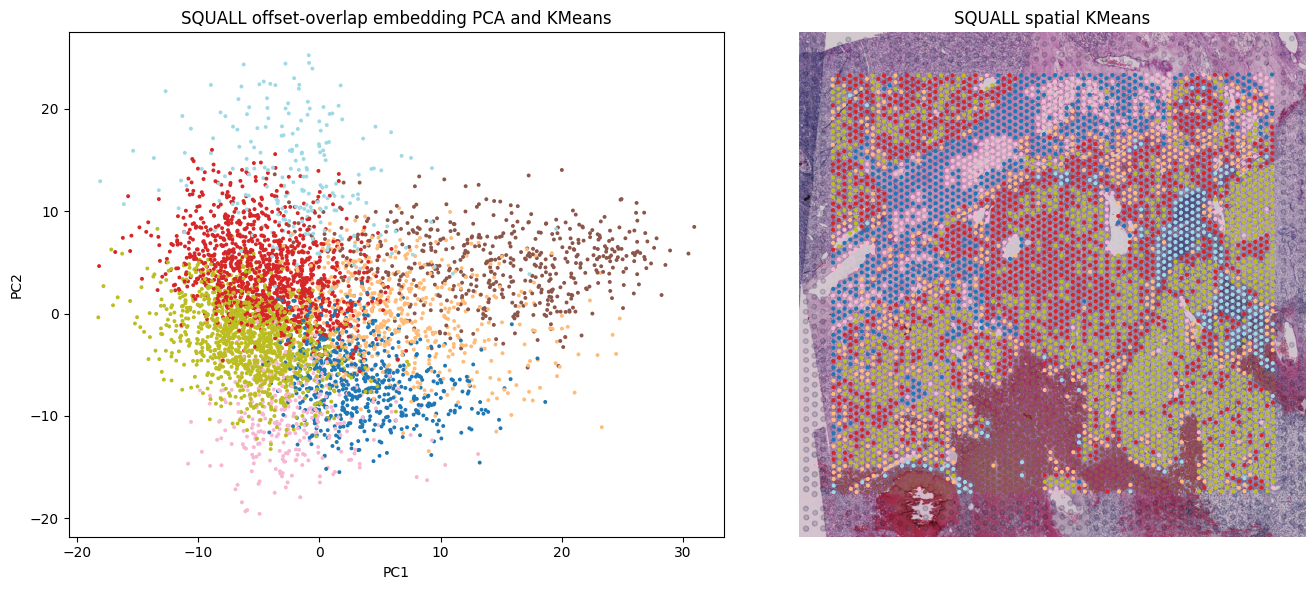

In [25]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
axes[0].scatter(spot.PC1,spot.PC2,c=codes,s=8,cmap='tab20',linewidths=0)
axes[0].set_title('SQUALL offset-overlap embedding PCA and KMeans')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[1].imshow(image)
axes[1].scatter(spot.pxl_col_in_fullres*hires_scale,spot.pxl_row_in_fullres*hires_scale,c=codes,s=9,cmap='tab20',linewidths=0)
axes[1].set_xlim(0,image.shape[1])
axes[1].set_ylim(image.shape[0],0)
axes[1].axis('off')
axes[1].set_title('SQUALL spatial KMeans')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'HM0543_SQUALL_offset_overlap_KMeans.png',dpi=250,bbox_inches='tight')
plt.show()

In [26]:
np.save(OUTPUT_DIR/'HM0543_SQUALL_spot_embedding.npy',embedding.astype(np.float32))
np.save(OUTPUT_DIR/'HM0543_SQUALL_embedding_grid.npy',embedding_grid.astype(np.float32))
np.save(OUTPUT_DIR/'HM0543_SQUALL_count_grid.npy',count_grid)
spot.to_csv(OUTPUT_DIR/'HM0543_SQUALL_clusters.csv',index=False)
run_metadata={'sample':'HM0543','checkpoint':str(SQUALL_CHECKPOINT),'config':str(SQUALL_CONFIG),'patch_size':PATCH_SIZE,'stride':STRIDE,'resolution':RESOLUTION,'clusters':N_CLUSTERS,'spots':len(spot),'embedding_shape':list(embedding.shape)}
(OUTPUT_DIR/'HM0543_SQUALL_run_metadata.json').write_text(json.dumps(run_metadata,indent=2))
print(OUTPUT_DIR.resolve())

/home/qinbw/STORM_codebase/squall_visium_clustering_output_HM0543
